# Evaluación 3 · Sección 7 — Contrastes y primer modelo

Continuación de `Contreras_Daniela-Nicklichen_Emanuel_Evaluacion_3_S6_Base.ipynb`.

**Alcance de este notebook:** contrastar la hipótesis tal como fue formulada, responder la dimensión socioeconómica que quedó pendiente, y ajustar el primer modelo del proyecto con su incertidumbre.

**Sobre el entorno:** se incorpora `statsmodels` al proyecto por el uso de regresión logística y de Poisson. Queda registrado en `pyproject.toml` y `uv.lock`, con el mismo criterio de reproducibilidad declarado en S0.

## 7.1 Carga de la base

Este notebook no recalcula nada: lee la tabla que produjo la Sección 6. Los contrastes y modelos se hacen sobre los postulantes **habilitados** sin selección (Sección 6, 6.8); los no habilitados solo aparecen en el recuento de 7.2.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint, proportions_ztest

DIRECTORIO_ACTUAL = Path.cwd()
DIRECTORIO_RAIZ = DIRECTORIO_ACTUAL.parent
RUTA_BASE = DIRECTORIO_RAIZ / "data" / "processed" / "base_no_seleccionados.csv"

base_completa = pd.read_csv(RUTA_BASE)

# Un no habilitado no podia quedar seleccionado en ningun programa (Seccion 6, 6.8).
# Los contrastes y modelos se hacen solo sobre los habilitados.
base = base_completa[base_completa["habilitado"]].copy()

# Los graficos se guardan como PNG en docs/figuras, para slides e informe
FIGURAS_DIR = DIRECTORIO_RAIZ / "docs" / "figuras"
FIGURAS_DIR.mkdir(parents=True, exist_ok=True)

def guardar(fig, nombre):
    ruta = FIGURAS_DIR / f"{nombre}.png"
    fig.savefig(ruta, dpi=200, bbox_inches="tight")
    print("Figura guardada:", ruta.name)

# Orden fijo de dependencias, de menor a mayor selectividad del establecimiento.
# La primera categoria es la referencia de los modelos.
ORDEN_DEP = ["Municipal","Corp. Municipal","SLEP","Corp. Adm. Delegada",
             "Part. Subvencionado","Part. Pagado"]
base["dep"] = pd.Categorical(base["DEP_NOMBRE"], categories=ORDEN_DEP)

# El decil 99 es "prefiere no responder" (Seccion 1). En vez de excluirlo, entra
# como categoria propia: asi el modelo no pierde uno de cada cuatro casos.
CATEGORIAS_DECIL = [str(i) for i in range(1, 11)] + ["No responde"]
base["decil_cat"] = pd.Categorical(
    base["decil"].astype(str).replace({"99": "No responde"}),
    categories=CATEGORIAS_DECIL)

base["y"] = base["tiene_alternativa"].astype(int)

print("No seleccionados:", len(base_completa))
print("Habilitados, poblacion de los analisis:", len(base))
print("Con alternativa alcanzable:", base["y"].sum(), f'({base["y"].mean()*100:.2f}%)')

No seleccionados: 27492
Habilitados, poblacion de los analisis: 22218
Con alternativa alcanzable: 15772 (70.99%)


## 7.2 El resultado en cuatro estados

Quedar sin alternativa no es una sola situación. La Sección 6 separó cuatro casos: tres entre los habilitados, y los que postularon sin estar habilitados.

In [2]:
# Cuatro estados sobre todos los no seleccionados
tabla_estados = base_completa["estado4"].value_counts().rename("Estudiantes").to_frame()
tabla_estados["%"] = (tabla_estados["Estudiantes"] / len(base_completa) * 100).round(2)

# Tres estados sobre los habilitados, que son la poblacion de todo lo que sigue
tabla_habilitados = base["estado3"].value_counts().rename("Estudiantes").to_frame()
tabla_habilitados["%"] = (tabla_habilitados["Estudiantes"] / len(base) * 100).round(2)

# El mejor puntaje solo existe para quienes tenian algun programa candidato.
puntaje_por_estado = (base[base["n_oportunidades"] > 0]
                      .groupby("estado3")["mejor_puntaje"]
                      .agg(["count", "mean", "median"]).round(1))
puntaje_por_estado.columns = ["N", "Media", "Mediana"]

print("Todos los no seleccionados:")
print(tabla_estados)
print()
print("Solo habilitados:")
print(tabla_habilitados)
print()
print("Mejor puntaje ponderado, habilitados con algun programa candidato:")
print(puntaje_por_estado)

Todos los no seleccionados:
                              Estudiantes      %
estado4                                         
Con alternativa alcanzable          15772  57.37
No habilitado para postular          5274  19.18
Con candidatos, sin alcanzar         4028  14.65
Sin candidatos evaluables            2418   8.80

Solo habilitados:
                              Estudiantes      %
estado3                                         
Con alternativa alcanzable          15772  70.99
Con candidatos, sin alcanzar         4028  18.13
Sin candidatos evaluables            2418  10.88

Mejor puntaje ponderado, habilitados con algun programa candidato:
                                  N  Media  Mediana
estado3                                            
Con alternativa alcanzable    15772  634.8    623.1
Con candidatos, sin alcanzar   4028  741.2    765.7


Figura guardada: s7_01_estados.png


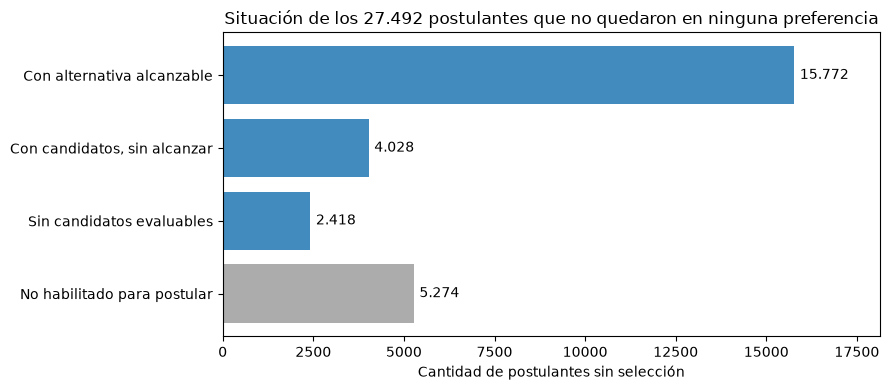

In [3]:
orden_estados = ["Con alternativa alcanzable", "Con candidatos, sin alcanzar",
                 "Sin candidatos evaluables", "No habilitado para postular"]
valores = [tabla_estados.loc[e, "Estudiantes"] for e in orden_estados]

# El no habilitado va en gris: no compite, queda fuera por construccion
colores = ["#1f77b4", "#1f77b4", "#1f77b4", "#9e9e9e"]

fig, ax = plt.subplots(figsize=(9, 4))
barras = ax.barh(orden_estados[::-1], valores[::-1], color=colores[::-1], alpha=0.85)
ax.set_xlabel("Cantidad de postulantes sin selección")
titulo = f"Situación de los {len(base_completa):,} postulantes que no quedaron en ninguna preferencia"
ax.set_title(titulo.replace(",", "."))
ax.bar_label(barras, labels=[f"{v:,}".replace(",", ".") for v in valores[::-1]], padding=4)
ax.set_xlim(0, max(valores) * 1.15)
plt.tight_layout()
guardar(fig, "s7_01_estados")
plt.show()

De los 27.492 que no quedaron en ninguna preferencia, 5.274 (19,18%) postularon sin estar habilitados: quedaron fuera por construcción, antes de competir.

Entre los 22.218 habilitados, el **70,99%** superaba el corte de al menos un programa de su área de interés con matrícula bajo las vacantes informadas. El 18,13% tenía candidatos pero no alcanzó ninguno, y el 10,88% no tenía ningún programa comparable que evaluar.

Entre quienes tenían candidatos, el grupo que **no** alcanzó ninguno presenta un mejor puntaje promedio más alto (741,2) que el grupo que sí lo logró (634,8). El resultado no depende solo del nivel de puntaje, sino de la selectividad de las carreras a las que ese puntaje apunta.

## 7.3 Contraste de la hipótesis

La hipótesis de la formulación afirma que la proporción con alternativa alcanzable es **mayor** en establecimientos particulares pagados que en públicos (Corporación Municipal, Municipal y SLEP). Hasta ahora se habían comparado las seis dependencias por separado, que no es lo mismo.

In [4]:
contraste = base[base["grupo_hipotesis"].isin(["Part. Pagado", "Publico"])]

tabla_hip = contraste.groupby("grupo_hipotesis")["y"].agg(["size", "sum"])
tabla_hip.columns = ["N", "Con alternativa"]
tabla_hip["%"] = (tabla_hip["Con alternativa"] / tabla_hip["N"] * 100).round(2)

# Intervalo de Wilson: mas confiable que el normal cuando la proporcion se aleja de 0,5
ic_inf, ic_sup = proportion_confint(tabla_hip["Con alternativa"], tabla_hip["N"],
                                    alpha=0.05, method="wilson")
tabla_hip["IC 95% inf"] = (ic_inf * 100).round(2)
tabla_hip["IC 95% sup"] = (ic_sup * 100).round(2)

tabla_hip

,N,Con alternativa,%,IC 95% inf,IC 95% sup
grupo_hipotesis,,,,,
Part. Pagado,2492,1383,55.50,53.54,57.44
Publico,6580,5000,75.99,74.94,77.00


In [5]:
pagado = tabla_hip.loc["Part. Pagado"]
publico = tabla_hip.loc["Publico"]

diferencia = pagado["%"] - publico["%"]
z, p_valor = proportions_ztest([pagado["Con alternativa"], publico["Con alternativa"]],
                               [pagado["N"], publico["N"]])

odds_pagado = pagado["Con alternativa"] / (pagado["N"] - pagado["Con alternativa"])
odds_publico = publico["Con alternativa"] / (publico["N"] - publico["Con alternativa"])

print(f"Diferencia (Part. Pagado - Publico): {diferencia:.2f} puntos porcentuales")
print(f"Razon de odds: {odds_pagado/odds_publico:.3f}")
print(f"Test de dos proporciones: z = {z:.2f}, p = {p_valor:.2e}")

Diferencia (Part. Pagado - Publico): -20.49 puntos porcentuales
Razon de odds: 0.394
Test de dos proporciones: z = -19.08, p = 4.03e-81


Figura guardada: s7_02_hipotesis_pp_publico.png


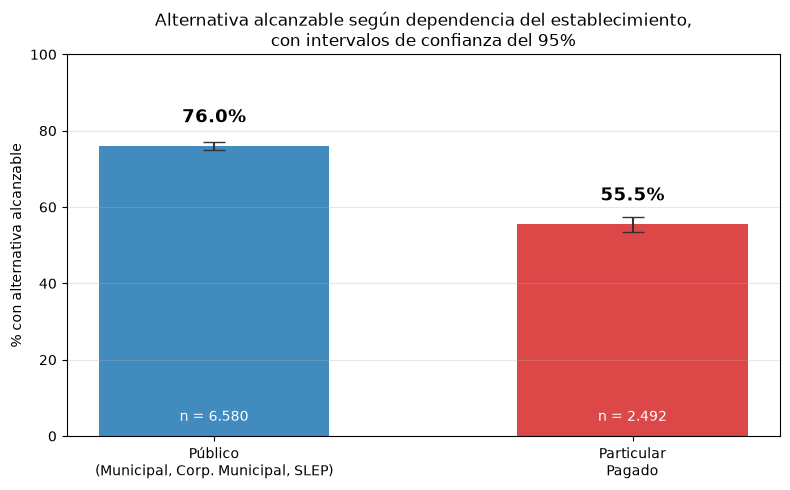

In [6]:
# Grafico del contraste: dos barras con sus intervalos. Se ordenan con Publico
# primero para que la caida de Particular Pagado se lea de izquierda a derecha.
grupos = ["Publico", "Part. Pagado"]
etiquetas = ["Público\n(Municipal, Corp. Municipal, SLEP)", "Particular\nPagado"]

valores = [tabla_hip.loc[g, "%"] for g in grupos]
error_inf = [tabla_hip.loc[g, "%"] - tabla_hip.loc[g, "IC 95% inf"] for g in grupos]
error_sup = [tabla_hip.loc[g, "IC 95% sup"] - tabla_hip.loc[g, "%"] for g in grupos]

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(etiquetas, valores, color=["#1f77b4", "#d62728"], alpha=0.85, width=0.55)
ax.errorbar(etiquetas, valores, yerr=[error_inf, error_sup],
            fmt="none", ecolor="#333333", capsize=8, linewidth=1.5)

ax.set_ylabel("% con alternativa alcanzable")
ax.set_title("Alternativa alcanzable según dependencia del establecimiento,\ncon intervalos de confianza del 95%")
ax.set_ylim(0, 100)
ax.bar_label(barras, fmt="%.1f%%", padding=14, fontsize=13, fontweight="bold")

# El n de cada grupo va dentro de la barra, para no competir con el porcentaje
for i, grupo in enumerate(grupos):
    ax.text(i, 4, f'n = {tabla_hip.loc[grupo, "N"]:,}'.replace(",", "."),
            ha="center", color="white", fontsize=10)

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
guardar(fig, "s7_02_hipotesis_pp_publico")
plt.show()

**Decisión documentada:** la hipótesis **no se sostiene tal como fue formulada, y el resultado corre en la dirección contraria**. La proporción con alternativa alcanzable es de 55,50% en Particular Pagado y 75,99% en establecimientos públicos: una diferencia de −20,49 puntos porcentuales, con intervalos de confianza que no se traslapan. La hipótesis se mantiene tal como fue escrita y se reporta que la evidencia la contradice; no se redefine para acomodar el resultado.

## 7.4 La dimensión socioeconómica

La pregunta de investigación menciona dependencia **y/o** nivel socioeconómico. Hasta la Evaluación 2 el decil se había cruzado con los puntajes, pero nunca con el resultado del proyecto.

In [7]:
por_decil = base[base["decil"] != 99].groupby("decil")["y"].agg(["size", "sum"])
por_decil.columns = ["N", "Con alternativa"]
por_decil["%"] = (por_decil["Con alternativa"] / por_decil["N"] * 100).round(1)

ic_inf, ic_sup = proportion_confint(por_decil["Con alternativa"], por_decil["N"],
                                    alpha=0.05, method="wilson")
por_decil["IC 95% inf"] = (ic_inf * 100).round(1)
por_decil["IC 95% sup"] = (ic_sup * 100).round(1)

no_responde = base[base["decil"] == 99]
print(f'Sin respuesta de ingreso (codigo 99): N={len(no_responde)}, '
      f'{no_responde["y"].mean()*100:.1f}% con alternativa')
print()
por_decil

Sin respuesta de ingreso (codigo 99): N=6606, 70.1% con alternativa



,N,Con alternativa,%,IC 95% inf,IC 95% sup
decil,,,,,
1,2929,2171,74.1,72.5,75.7
2,2384,1749,73.4,71.6,75.1
3,1585,1106,69.8,67.5,72.0
4,1516,1110,73.2,70.9,75.4
5,1161,793,68.3,65.6,70.9
6,1092,762,69.8,67.0,72.4
7,1727,1283,74.3,72.2,76.3
8,1409,1048,74.4,72.0,76.6
9,873,570,65.3,62.1,68.4


Figura guardada: s7_03_decil.png


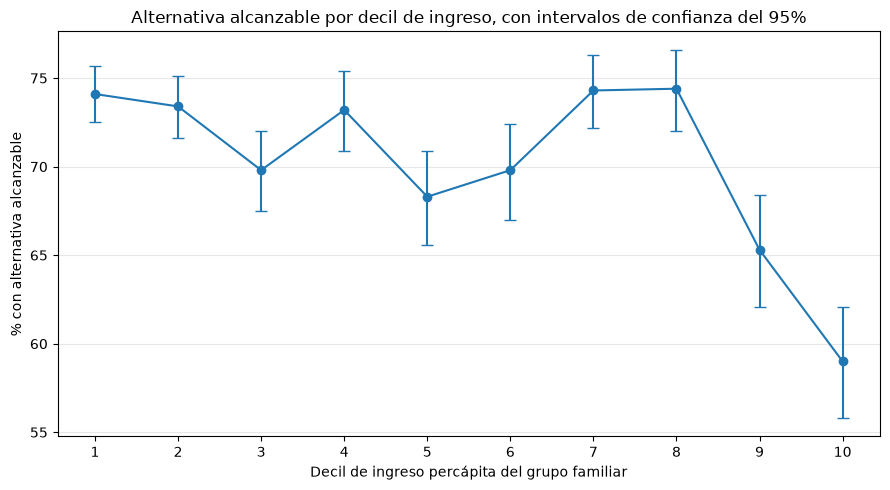

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

# Las barras de error van como distancia al punto, no como limites absolutos
error_inf = por_decil["%"] - por_decil["IC 95% inf"]
error_sup = por_decil["IC 95% sup"] - por_decil["%"]

ax.errorbar(por_decil.index, por_decil["%"], yerr=[error_inf, error_sup],
            marker="o", capsize=4, color="#1f77b4")
ax.set_xlabel("Decil de ingreso percápita del grupo familiar")
ax.set_ylabel("% con alternativa alcanzable")
ax.set_title("Alternativa alcanzable por decil de ingreso, con intervalos de confianza del 95%")
ax.set_xticks(range(1, 11))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
guardar(fig, "s7_03_decil")
plt.show()

La relación no es monótona. Entre los deciles 1 y 8 la proporción oscila entre 68,3% y 74,4% sin una dirección definida: hay variaciones puntuales (el decil 5 queda por debajo del 1 y del 8, con intervalos que no se traslapan), pero no una tendencia por ingreso. La caída clara está en el extremo: 65,3% en el decil 9 y 59,0% en el 10, este último por debajo de todos los demás.

Es el mismo patrón que muestra Particular Pagado, lo cual es esperable porque son poblaciones que se solapan. Los 6.606 que no informan ingreso se reportan aparte (70,1%) y no se imputan.

## 7.5 Primer modelo: diferencia sin ajustar

La variable respuesta es binaria, así que la herramienta que corresponde es una regresión logística. Una regresión lineal podría predecir probabilidades fuera del rango 0-1.

Este primer modelo estima la asociación **cruda** entre dependencia y resultado, sin controlar por nada. La categoría de referencia es Municipal.

In [9]:
modelo_1 = smf.logit("y ~ C(dep)", data=base.dropna(subset=["dep"])).fit(disp=0)

# Los coeficientes de una logistica estan en log-odds. Se exponencian para
# leerlos como razones de odds, que es como se reportan.
resultado_1 = pd.DataFrame({
    "OR": np.exp(modelo_1.params),
    "IC 95% inf": np.exp(modelo_1.conf_int()[0]),
    "IC 95% sup": np.exp(modelo_1.conf_int()[1]),
    "p": modelo_1.pvalues,
}).round(3)

print("Modelo 1 — referencia: Municipal")
print("n =", int(modelo_1.nobs), " | pseudo R2 =", round(modelo_1.prsquared, 4))
print()
resultado_1

Modelo 1 — referencia: Municipal
n = 21981  | pseudo R2 = 0.0137



,OR,IC 95% inf,IC 95% sup,p
Intercept,3.374,3.109,3.662,0.000
C(dep)[T.Corp. Municipal],0.874,0.752,1.016,0.081
C(dep)[T.SLEP],0.888,0.780,1.010,0.071
C(dep)[T.Corp. Adm. Delegada],0.951,0.775,1.166,0.629
C(dep)[T.Part. Subvencionado],0.726,0.663,0.795,0.000
C(dep)[T.Part. Pagado],0.370,0.330,0.414,0.000


Sin ajustar, un estudiante de Particular Pagado tiene odds de 0,370 respecto de uno municipal (IC 95% [0,330 – 0,414]): algo más de un tercio. Es la misma brecha de 7.3, ahora expresada como modelo.

## 7.6 Segundo modelo: ajustando por puntaje y nivel socioeconómico

La pregunta que importa no es si existe una diferencia bruta, sino si **persiste al comparar estudiantes equivalentes**. Se agregan el decil de ingreso (como categórico, porque el EDA mostró que la relación no es lineal) y el promedio de las pruebas obligatorias.

In [10]:
datos_modelo = base.dropna(subset=["dep", "decil_cat", "ptje_obligatorias"])

modelo_2 = smf.logit("y ~ C(dep) + C(decil_cat) + ptje_obligatorias",
                     data=datos_modelo).fit(disp=0)

resultado_2 = pd.DataFrame({
    "OR": np.exp(modelo_2.params),
    "IC 95% inf": np.exp(modelo_2.conf_int()[0]),
    "IC 95% sup": np.exp(modelo_2.conf_int()[1]),
    "p": modelo_2.pvalues,
}).round(3)

print("Modelo 2 — referencia: Municipal, decil 1")
print("n =", int(modelo_2.nobs), " | pseudo R2 =", round(modelo_2.prsquared, 4))
print()
resultado_2

Modelo 2 — referencia: Municipal, decil 1
n = 21981  | pseudo R2 = 0.1506



,OR,IC 95% inf,IC 95% sup,p
Intercept,603.548,483.132,753.978,0.000
C(dep)[T.Corp. Municipal],1.167,0.988,1.379,0.070
C(dep)[T.SLEP],0.820,0.713,0.943,0.006
C(dep)[T.Corp. Adm. Delegada],0.799,0.644,0.993,0.043
C(dep)[T.Part. Subvencionado],0.941,0.852,1.040,0.234
C(dep)[T.Part. Pagado],1.336,1.163,1.536,0.000
C(decil_cat)[T.2],1.011,0.883,1.157,0.878
C(decil_cat)[T.3],1.000,0.860,1.163,0.998
C(decil_cat)[T.4],1.160,0.992,1.356,0.063
C(decil_cat)[T.5],0.898,0.761,1.059,0.200


**Al comparar estudiantes equivalentes, el efecto de Particular Pagado se invierte.** Pasa de `OR = 0,370` a `OR = 1,336`, con un intervalo de [1,163 – 1,536] que queda completo por sobre el 1. A igual decil y puntaje, un estudiante de Particular Pagado tiene odds un 34% **mayores** que uno municipal de tener una alternativa alcanzable. Ninguno de los deciles resulta distinguible del decil 1 una vez incluido el puntaje.

El puntaje va en la dirección contraria: `OR = 0,991` por punto. A **mayor** puntaje, **menor** probabilidad de tener una alternativa alcanzable; diez puntos más reducen las odds cerca de un 9%.

El pseudo R² sube de 0,014 a 0,151: casi todo el poder explicativo lo aporta el puntaje.

## 7.7 Qué significa en probabilidades

Las razones de odds son difíciles de leer. Se traducen a probabilidad predicha, fijando a todos los estudiantes en el mismo decil y el mismo puntaje, para ver qué queda de la brecha.

In [11]:
escenario = pd.DataFrame({"dep": pd.Categorical(ORDEN_DEP, categories=ORDEN_DEP)})
escenario["decil_cat"] = pd.Categorical(["3"] * len(ORDEN_DEP), categories=CATEGORIAS_DECIL)
escenario["ptje_obligatorias"] = datos_modelo["ptje_obligatorias"].median()

prediccion = modelo_2.get_prediction(escenario).summary_frame(alpha=0.05)

# El nombre de estas columnas cambia entre versiones de statsmodels.
# Se resuelve por nombre para que el notebook no dependa de una version puntual.
cols = {nombre.lower(): nombre for nombre in prediccion.columns}
col_prob = cols.get("predicted", cols.get("mean"))
col_inf = cols.get("ci_lower", cols.get("mean_ci_lower"))
col_sup = cols.get("ci_upper", cols.get("mean_ci_upper"))

observado = base.groupby("DEP_NOMBRE")["y"].mean().reindex(ORDEN_DEP) * 100

comparacion = pd.DataFrame({
    "Observado %": observado.values.round(1),
    "Ajustado %": (prediccion[col_prob].values * 100).round(1),
    "IC 95% inf": (prediccion[col_inf].values * 100).round(1),
    "IC 95% sup": (prediccion[col_sup].values * 100).round(1),
    "Puntaje promedio": base.groupby("DEP_NOMBRE")["ptje_obligatorias"].mean().reindex(ORDEN_DEP).round(0).values,
}, index=ORDEN_DEP)

print(f'Escenario: decil 3, puntaje obligatorias = {escenario["ptje_obligatorias"].iloc[0]:.0f}')
print()
comparacion

Escenario: decil 3, puntaje obligatorias = 582



,Observado %,Ajustado %,IC 95% inf,IC 95% sup,Puntaje promedio
Municipal,77.1,78.9,76.4,81.2,576.0
Corp. Municipal,74.7,81.4,78.4,84.0,606.0
SLEP,75.0,75.4,72.4,78.2,570.0
Corp. Adm. Delegada,76.2,74.9,70.4,79.0,563.0
Part. Subvencionado,71.0,77.9,75.7,80.0,608.0
Part. Pagado,55.5,83.3,80.9,85.5,732.0


Figura guardada: s7_04_observado_ajustado.png


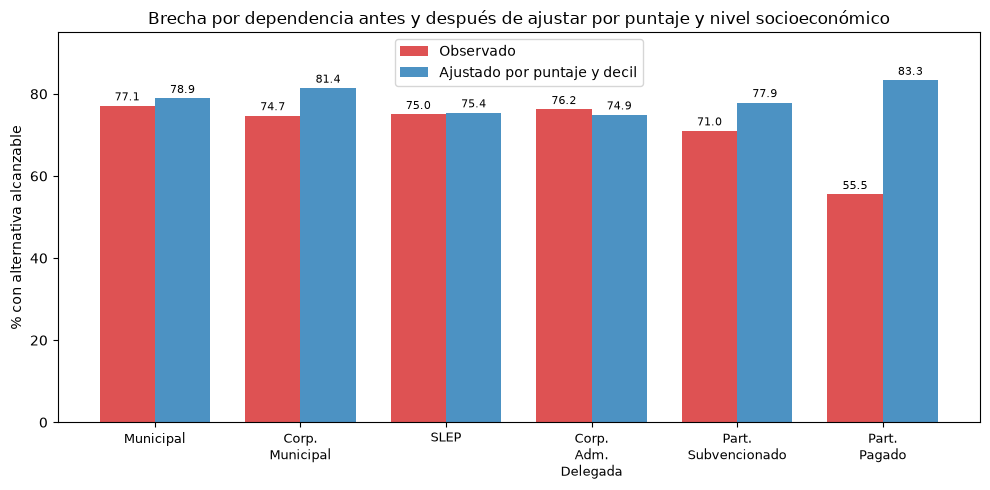

In [12]:
x = np.arange(len(ORDEN_DEP))
ancho = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - ancho/2, comparacion["Observado %"], ancho,
            label="Observado", color="#d62728", alpha=0.8)
b2 = ax.bar(x + ancho/2, comparacion["Ajustado %"], ancho,
            label="Ajustado por puntaje y decil", color="#1f77b4", alpha=0.8)

ax.set_ylabel("% con alternativa alcanzable")
ax.set_title("Brecha por dependencia antes y después de ajustar por puntaje y nivel socioeconómico")
ax.set_xticks(x)
ax.set_xticklabels([d.replace(" ", "\n") for d in ORDEN_DEP], fontsize=9)
ax.bar_label(b1, fmt="%.1f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.1f", padding=2, fontsize=8)
ax.legend()
ax.set_ylim(0, 95)
plt.tight_layout()
guardar(fig, "s7_04_observado_ajustado")
plt.show()

**Decisión documentada:** al comparar estudiantes con el mismo decil y el mismo puntaje, Particular Pagado pasa de la proporción observada más baja (55,5%) a la ajustada más alta (83,3%, frente a 78,9% de Municipal). La brecha observada de 21,6 puntos no solo se cierra: se invierte.

La razón es que el puntaje es un **mediador**, no un confusor (clase 4). Los estudiantes de Particular Pagado promedian 732 puntos contra 576 de los municipales, apuntan a carreras más selectivas, y esas carreras no dejan cupos sin llenar. Ese camino a través del puntaje pesa más que la ventaja que Particular Pagado muestra a igual puntaje, y la tapa en la comparación directa.

Es una asociación descrita, no una relación causal establecida: el modelo no identifica por qué existe la ventaja a igual puntaje.

## 7.8 El mecanismo: cuántas alternativas hay disponibles

Si la explicación es que los estudiantes de Particular Pagado persiguen carreras con menos sustitutos, eso debería verse directamente en cuántos programas candidatos tiene cada uno. Se modela el número de oportunidades como variable respuesta.

Es un conteo, así que corresponde una regresión de Poisson. Los datos están sobredispersos (la varianza supera con holgura a la media), por lo que se usan errores estándar robustos.

In [13]:
datos_poisson = base.dropna(subset=["dep", "ptje_obligatorias"])

print("n_oportunidades — media:", round(datos_poisson["n_oportunidades"].mean(), 1),
      "| varianza:", round(datos_poisson["n_oportunidades"].var(), 1))

# Modelo crudo: solo dependencia
poisson_1 = smf.poisson("n_oportunidades ~ C(dep)",
                        data=datos_poisson).fit(disp=0, cov_type="HC1")

# Modelo ajustado: se agregan puntaje y amplitud de la lista de preferencias
poisson_2 = smf.poisson("n_oportunidades ~ C(dep) + ptje_obligatorias + n_carreras_distintas",
                        data=datos_poisson).fit(disp=0, cov_type="HC1")

def tabla_irr(modelo):
    return pd.DataFrame({
        "IRR": np.exp(modelo.params),
        "IC 95% inf": np.exp(modelo.conf_int()[0]),
        "IC 95% sup": np.exp(modelo.conf_int()[1]),
    }).round(3)

print()
print("Crudo — referencia: Municipal")
print(tabla_irr(poisson_1))
print()
print("Ajustado por puntaje y amplitud de la lista")
print(tabla_irr(poisson_2))

n_oportunidades — media: 15.1 | varianza: 368.1

Crudo — referencia: Municipal
                                  IRR  IC 95% inf  IC 95% sup
Intercept                      19.334      18.543      20.159
C(dep)[T.Corp. Municipal]       0.822       0.760       0.890
C(dep)[T.SLEP]                  0.831       0.778       0.888
C(dep)[T.Corp. Adm. Delegada]   0.752       0.675       0.838
C(dep)[T.Part. Subvencionado]   0.753       0.719       0.790
C(dep)[T.Part. Pagado]          0.559       0.523       0.598

Ajustado por puntaje y amplitud de la lista
                                  IRR  IC 95% inf  IC 95% sup
Intercept                      70.037      63.737      76.959
C(dep)[T.Corp. Municipal]       0.929       0.864       0.998
C(dep)[T.SLEP]                  0.848       0.802       0.896
C(dep)[T.Corp. Adm. Delegada]   0.805       0.732       0.885
C(dep)[T.Part. Subvencionado]   0.896       0.861       0.933
C(dep)[T.Part. Pagado]          1.074       1.009       1.144
ptje_obl

Sin ajustar, un estudiante de Particular Pagado evalúa **cerca de la mitad** de las oportunidades que uno municipal (`IRR = 0,559`, IC 95% [0,523 – 0,598]). En promedio son 10,8 programas contra 19,3.

Al controlar por puntaje y por cuántas carreras distintas incluyó en su lista, el signo también se invierte: `IRR = 1,074` [1,009 – 1,144]. A igual puntaje y a igual amplitud de lista, Particular Pagado evalúa un 7% **más** de oportunidades. Es el mismo patrón del modelo logístico, medido desde otra variable.

Salvedad: `n_carreras_distintas` y `n_oportunidades` están ligadas por construcción, porque los programas candidatos se buscan entre las carreras que el propio estudiante nombró. Controlar por ella acota la pregunta a "igual puntaje e igual amplitud de lista"; no aísla un confusor.

## 7.9 Análisis de sensibilidad

El resultado central usa la comparación estricta `puntaje > corte`. Un estudiante con puntaje exactamente igual al menor seleccionado queda clasificado como insuficiente, lo que es discutible.

In [14]:
estricto = (base["n_supera"] > 0).sum()
con_empate = (base["n_supera_con_empate"] > 0).sum()

sensibilidad = pd.DataFrame({
    "Criterio": ["puntaje > corte (estricto)", "puntaje >= corte (incluye empate)"],
    "Con alternativa": [estricto, con_empate],
    "%": [round(estricto/len(base)*100, 2), round(con_empate/len(base)*100, 2)],
})

sensibilidad

,Criterio,Con alternativa,%
0,puntaje > corte (estricto),15772,70.99
1,puntaje >= corte (incluye empate),15772,70.99


La diferencia es de cero casos entre los 22.218 habilitados. El resultado no depende del criterio de empate, así que se conserva la comparación estricta y se deja constancia de la verificación.

## 7.10 Síntesis de la sección

- **Siete de cada diez habilitados que quedaron fuera tenían dónde ir** (70,99%). Otros 5.274 postularon sin estar habilitados y quedaron fuera por construcción.
- **La hipótesis no se sostiene tal como fue formulada.** 55,50% en Particular Pagado contra 75,99% en establecimientos públicos: 20,5 puntos en contra, con intervalos que no se traslapan.
- **A igual puntaje y decil, la brecha se invierte.** El OR de Particular Pagado pasa de 0,370 a 1,336 [1,163 – 1,536], y su probabilidad ajustada es la más alta de las seis dependencias (83,3%).
- **El puntaje explica la inversión.** A mayor puntaje, menor probabilidad de tener alternativa (OR = 0,991 por punto): quien rinde mejor apunta a carreras más selectivas, que no dejan vacantes sin llenar. Es un mediador, no un confusor.
- **El nivel socioeconómico muestra el mismo patrón de extremo:** sin tendencia entre los deciles 1 y 8 (oscila entre 68% y 74%), con caída en el 9 y hasta 59,0% en el 10. Una vez incluido el puntaje en el modelo, ningún decil se distingue del 1.
- **El mecanismo coincide:** sin ajustar, Particular Pagado evalúa cerca de la mitad de las oportunidades (IRR = 0,559); a igual puntaje y amplitud de lista, un 7% más (IRR = 1,074).

## Uso de Inteligencia Artificial

Se utilizó **Claude (Anthropic)** como asistente para la construcción de este notebook: la especificación de los modelos, la elección de errores estándar robustos ante sobredispersión, la traducción de razones de odds a probabilidades predichas y la redacción de las interpretaciones. La hipótesis, la definición del grupo de contraste y la decisión de no redefinirla tras conocer los resultados son del equipo, así como la verificación de cada cifra reportada. Todas las cifras son reproducibles sobre `data/processed/base_no_seleccionados.csv`, generado por la Sección 6 a partir de las bases públicas declaradas.